# [KDD 2026 AI4Sci] StageGuard - interactive demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Q9gJYx/StageGuard/blob/main/notebooks/demo_stageguard.ipynb)
[![KDD 2026](https://img.shields.io/badge/KDD-2026%20AI4Sci-1d4ed8.svg)](https://doi.org/10.1145/3770855.3818916)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](https://github.com/Q9gJYx/StageGuard/blob/main/LICENSE)

**StageGuard** wraps any neural sleep-staging backbone with physiology-informed priors: a soft
transition penalty at training time and a **semi-Markov constrained decoder** at inference time.

This notebook demonstrates the inference-time decoder on **real PSG hypnograms** from the open
[Sleep-Accel](https://physionet.org/content/sleep-accel/1.0.0/) dataset (ODC-By), comparing:

- **Unconstrained** backbone output (`argmax` of per-epoch probabilities), vs
- **StageGuard** (semi-Markov constrained decode).

It shows StageGuard drives the **transition-violation rate (TVR)** and **fragmentation index (FI)** down
while **holding or improving accuracy** - then visualizes the three hypnograms.

> **Note.** No trained weights are shipped. A small, clearly-labeled *simulated* noisy backbone fabricates
> per-epoch probabilities from the ground-truth hypnogram (fixed seed) purely to exercise the decoder.
> Runtime: a few seconds on CPU. No GPU, no downloads beyond the repo.

## Setup
On Colab this clones the repo and installs the package. Locally (run from the repo root) it is a no-op.

In [1]:
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("StageGuard"):
        !git clone -q https://github.com/Q9gJYx/StageGuard.git
    %cd StageGuard
    !pip install -q -e .
# Ensure cwd is the repo root so configs/ and data/ resolve when run locally.
if not os.path.exists("configs") and os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Running in Colab:", IN_COLAB)

Running in Colab: False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from stageguard.config import ModalityConfig
from stageguard.decoder import SemiMarkovDecoder
from stageguard.metrics import (
    transition_violation_rate, fragmentation_index,
    classification_metrics, sleep_architecture,
)
SEED = 20260618

In [3]:
config = ModalityConfig.from_yaml("configs/sleepaccel_demo.yaml")
data = np.load("data/sleepaccel_demo.npz")
C = config.num_classes
epoch_sec = float(data["epoch_sec"])
stage_names = list(config.stage_names)
y_true = data["hypno_0"].astype(int)          # primary subject
T = len(y_true)
print(f"{config.dataset_name} | stages={stage_names} | rare transitions={config.rare_transitions}")
print(f"primary subject {data['subject_ids'][0]} | T={T} epochs ({T * epoch_sec / 3600:.1f} h)")

Sleep-Accel (demo, 3-state) | stages=['Wake', 'NREM', 'REM'] | rare transitions=[(0, 2), (2, 0)]
primary subject 4426783 | T=980 epochs (8.2 h)


## A simulated noisy backbone

The function below is **not** a trained model. It fabricates `(T, C)` **log-probabilities** around the true
hypnogram (so a backbone-like `argmax` is mostly correct), then injects two realistic error modes:

1. **Rare Wake↔REM violations** - a few REM epochs flipped to a confident *Wake* (raises TVR).
2. **Flip-flop fragmentation** - a few NREM epochs flipped to a confident wrong stage for one epoch (raises FI).

`SemiMarkovDecoder.decode` then has to recover the clean hypnogram from these corrupted emissions.

In [4]:
def simulate_backbone_logprobs(y_true, C, rng, *, base_conf=2.5, noise=0.8,
                               n_rare=12, n_flip=18, spike=5.0, flip=4.0):
    """Deterministic SIMULATED (T, C) log-probabilities - NOT a trained model.

    Confident-but-noisy logits around the true hypnogram, plus injected
    Wake<->REM violations (TVR) and single-epoch flip-flops (FI). Returns
    log-probabilities because SemiMarkovDecoder.decode expects log-prob input.
    """
    T = len(y_true)
    logits = rng.normal(0.0, noise, size=(T, C))
    logits[np.arange(T), y_true] += base_conf

    def mids(stage):  # interior epochs sitting inside a >=3-epoch bout of `stage`
        return [t for t in range(2, T - 2)
                if y_true[t - 1] == y_true[t] == y_true[t + 1] == stage]

    # (1) rare Wake<->REM: flip REM-bout interiors to a confident Wake -> REM,Wake,REM
    rem_mid = mids(2)
    for t in rng.choice(rem_mid, size=min(n_rare, len(rem_mid)), replace=False):
        logits[t, :] -= 1.0
        logits[t, 0] += spike
    # (2) flip-flops: flip NREM-bout interiors to a non-rare wrong stage (Wake or REM)
    nrem_mid = mids(1)
    for i, t in enumerate(rng.choice(nrem_mid, size=min(n_flip, len(nrem_mid)), replace=False)):
        logits[t, :] -= 1.0
        logits[t, 0 if i % 2 else 2] += flip

    logits -= logits.max(axis=1, keepdims=True)           # -> log-softmax (log-probs)
    return (logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))).astype(np.float64)


rng = np.random.default_rng(SEED)
log_probs = simulate_backbone_logprobs(y_true, C, rng)
print("log_probs:", log_probs.shape,
      "| rows normalized:", np.allclose(np.exp(log_probs).sum(1), 1.0))

log_probs: (980, 3) | rows normalized: True


In [5]:
decoder = SemiMarkovDecoder(config)
argmax_pred = log_probs.argmax(axis=1)        # unconstrained backbone output
sg_pred = decoder.decode(log_probs)           # StageGuard constrained decode

## Metrics: constraints satisfied, accuracy preserved

In [6]:
def rem_latency_min(seq):
    rem = stage_names.index("REM")
    idx = np.where(seq == rem)[0]
    return idx[0] * epoch_sec / 60.0 if len(idx) else float("nan")

def summarize(name, pred):
    cm = classification_metrics(y_true, pred, stage_names)
    return dict(name=name,
                TVR=transition_violation_rate(pred, config.rare_transitions),
                FI_per_h=fragmentation_index(pred) * 3600.0 / epoch_sec,
                acc=cm["accuracy"], kappa=cm["kappa"], REM_lat=rem_latency_min(pred))

rows = [summarize("Unconstrained (argmax)", argmax_pred),
        summarize("StageGuard decode", sg_pred),
        summarize("Ground truth (PSG)", y_true)]
print(f"{'method':24s} {'TVR':>7} {'FI/h':>7} {'acc':>7} {'kappa':>7} {'REMlat/m':>9}")
for r in rows:
    print(f"{r['name']:24s} {r['TVR']:7.3f} {r['FI_per_h']:7.1f} "
          f"{r['acc']:7.3f} {r['kappa']:7.3f} {r['REM_lat']:9.1f}")

method                       TVR    FI/h     acc   kappa  REMlat/m
Unconstrained (argmax)     0.028    17.0   0.945   0.896      28.0
StageGuard decode          0.000     4.9   0.984   0.969      73.5
Ground truth (PSG)         0.000     4.9   1.000   1.000      73.5


In [7]:
# Derived sleep-architecture statistics (not directly optimized by the decoder)
def arch(pred):
    a = sleep_architecture(pred, epoch_sec=epoch_sec, wake_label=0, stage_names=stage_names)
    return {k: round(a[k], 2) for k in ("tst_min", "sleep_efficiency", "waso_min", "awakenings")}

for name, pred in [("argmax", argmax_pred), ("StageGuard", sg_pred), ("truth", y_true)]:
    print(f"{name:11s}", arch(pred))

argmax      {'tst_min': 440.5, 'sleep_efficiency': 0.9, 'waso_min': 46.0, 'awakenings': 40.0}
StageGuard  {'tst_min': 452.0, 'sleep_efficiency': 0.92, 'waso_min': 25.0, 'awakenings': 12.0}
truth       {'tst_min': 455.0, 'sleep_efficiency': 0.93, 'waso_min': 22.0, 'awakenings': 11.0}


In [8]:
# Guard: fail loudly if the demo's story regresses.
tvr_a, tvr_s = rows[0]["TVR"], rows[1]["TVR"]
fi_a, fi_s = rows[0]["FI_per_h"], rows[1]["FI_per_h"]
acc_a, acc_s = rows[0]["acc"], rows[1]["acc"]
assert tvr_a > 0.01 and tvr_s <= tvr_a / 4, (tvr_a, tvr_s)
assert fi_a > fi_s, (fi_a, fi_s)
assert acc_s >= acc_a - 0.01, (acc_a, acc_s)
print("guard OK: TVR down, fragmentation down, accuracy held/improved")

guard OK: TVR down, fragmentation down, accuracy held/improved


## The three hypnograms

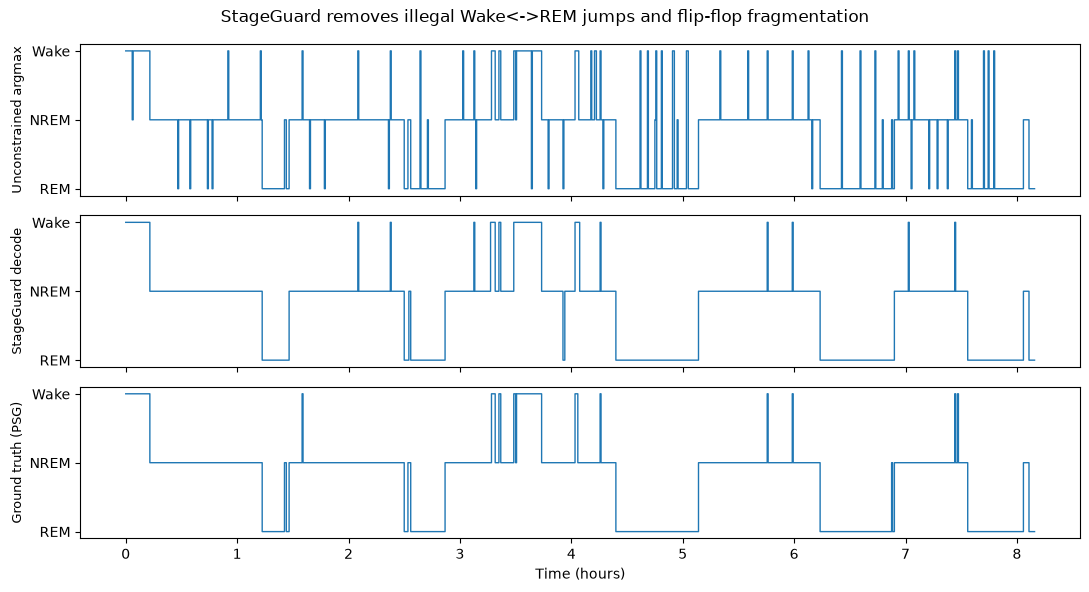

In [9]:
t_h = np.arange(T) * epoch_sec / 3600.0
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for ax, (title, seq) in zip(axes, [("Unconstrained argmax", argmax_pred),
                                   ("StageGuard decode", sg_pred),
                                   ("Ground truth (PSG)", y_true)]):
    ax.step(t_h, seq, where="post", lw=1.0)
    ax.set_yticks(range(C)); ax.set_yticklabels(stage_names)
    ax.set_ylabel(title, fontsize=9); ax.invert_yaxis()   # Wake on top (clinical convention)
axes[-1].set_xlabel("Time (hours)")
fig.suptitle("StageGuard removes illegal Wake<->REM jumps and flip-flop fragmentation")
fig.tight_layout(); plt.show()

## The same holds across all shipped subjects

In [10]:
print(f"{'subject':>9}   {'TVR (am->sg)':>14}   {'FI/h (am->sg)':>16}   {'acc (am->sg)':>14}")
for i in range(len(data["subject_ids"])):
    y = data[f"hypno_{i}"].astype(int)
    lp = simulate_backbone_logprobs(y, C, np.random.default_rng(SEED + i))
    am, sg = lp.argmax(1), decoder.decode(lp)
    tvr = (transition_violation_rate(am, config.rare_transitions),
           transition_violation_rate(sg, config.rare_transitions))
    fih = (fragmentation_index(am) * 3600 / epoch_sec,
           fragmentation_index(sg) * 3600 / epoch_sec)
    acc = (classification_metrics(y, am)["accuracy"],
           classification_metrics(y, sg)["accuracy"])
    print(f"{str(data['subject_ids'][i]):>9}   {tvr[0]:5.3f} -> {tvr[1]:<5.3f}   "
          f"{fih[0]:6.1f} -> {fih[1]:<6.1f}   {acc[0]:.3f} -> {acc[1]:.3f}")

  subject     TVR (am->sg)      FI/h (am->sg)     acc (am->sg)


  4426783   0.028 -> 0.000     17.0 -> 4.9      0.945 -> 0.984


   781756   0.039 -> 0.000     19.1 -> 5.1      0.942 -> 0.982
  9961348   0.042 -> 0.001     18.4 -> 4.2      0.939 -> 0.993


   759667   0.070 -> 0.000     25.3 -> 3.3      0.909 -> 0.981


  1066528   0.037 -> 0.000     17.5 -> 5.6      0.957 -> 0.979


## Signal-quality integration

Per-epoch signal-quality (SQI) scores let the decoder discount low-quality epochs: emissions are damped
toward uniform where SQI is low, so the physiological priors take over. Below, a short window inside a REM
bout is corrupted with confident-but-wrong "Wake" emissions (true REM left as the runner-up). With full trust
(no SQI) the decoder follows the corrupt signal; with low SQI over that window, the rare Wake<->REM prior
correctly overrides it and REM is preserved.

In [11]:
def runs_of(seq):
    out, i = [], 0
    while i < len(seq):
        j = i + 1
        while j < len(seq) and seq[j] == seq[i]:
            j += 1
        out.append((i, j, int(seq[i]))); i = j
    return out

# corrupt a short window inside the longest REM bout: confident "Wake", true REM as runner-up
rem = stage_names.index("REM")
i0, j0, _ = max((r for r in runs_of(y_true) if r[2] == rem), key=lambda r: r[1] - r[0])
L = 8
a = i0 + ((j0 - i0) - L) // 2; b = a + L

lp_bad = log_probs.copy()
lp_bad[a:b, :] = np.log([0.90, 0.02, 0.08])    # [Wake, NREM, REM]: confident-wrong Wake
sqi = np.ones(T); sqi[a:b] = 0.05              # mark the window low-quality (scores in [0, 1])

pred_no_sqi = decoder.decode(lp_bad)           # full trust -> follows the corrupt Wake
pred_sqi = decoder.decode(lp_bad, sqi)         # low SQI -> rare-transition prior preserves REM
acc_win = lambda p: float((p[a:b] == y_true[a:b]).mean())
print(f"REM-bout artifact window [{a}:{b}] REM accuracy  ->  "
      f"no SQI: {acc_win(pred_no_sqi):.2f}   with SQI: {acc_win(pred_sqi):.2f}")
assert acc_win(pred_sqi) > acc_win(pred_no_sqi), "SQI should recover the corrupt window"

REM-bout artifact window [568:576] REM accuracy  ->  no SQI: 0.00   with SQI: 1.00


## Training-side: the differentiable soft transition penalty

In [12]:
import torch
from stageguard.backbones import get_backbone
from stageguard.wrapper import StageGuardWrapper

backbone = get_backbone("accusleep", num_classes=C, in_channels=1)
model = StageGuardWrapper(backbone, config)
B, Tt, samples = 2, 40, 128
x = torch.randn(B, Tt, 1, samples)                         # (B, T, in_channels, epoch_samples)
targets = torch.randint(0, C, (B, Tt))
loss, details = model.training_step(x, targets)
print(f"total={loss.item():.4f}  ce={details['ce_loss'].item():.4f}  "
      f"trans={details['trans_loss'].item():.4f}  (random net -> small trans term)")
loss.backward()
print("backward OK: the soft transition penalty is differentiable")

total=1.3299  ce=1.0993  trans=0.2306  (random net -> small trans term)
backward OK: the soft transition penalty is differentiable


## Next steps

- Wrap your own backbone (any `nn.Module` returning `(B, T, C)` logits) - see
  [`docs/backbones.md`](https://github.com/Q9gJYx/StageGuard/blob/main/docs/backbones.md).
- Real datasets and access notes - see
  [`docs/datasets.md`](https://github.com/Q9gJYx/StageGuard/blob/main/docs/datasets.md).
- Paper: *StageGuard: Physiologically Constrained Sleep Staging*, KDD 2026 AI4Sciences,
  DOI [10.1145/3770855.3818916](https://doi.org/10.1145/3770855.3818916). Archival DOI (Zenodo): _pending_.
- Please cite via [`CITATION.cff`](https://github.com/Q9gJYx/StageGuard/blob/main/CITATION.cff).